# OIBSIP — Task 4: Email Spam Detection

Build an NLP classifier that distinguishes **spam** messages from legitimate (**ham**) messages using TF-IDF features.


## 1. Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Load Dataset

In [2]:
df = pd.read_csv("/Users/sakshamchauhan/Downloads/Github/OIBSIP/OIBSIP-DataScience-Task4-Email_Spam_Detection/spam.csv", encoding="latin-1")

# Keep only the useful columns
df = df[["v1", "v2"]].copy()
df.columns = ["label", "message"]

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Understand Dataset

In [3]:
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nClass percentage:")
print((df["label"].value_counts(normalize=True) * 100).round(2))
print("\nMissing values:")
print(df.isnull().sum())


Shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class percentage:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

Missing values:
label      0
message    0
dtype: int64


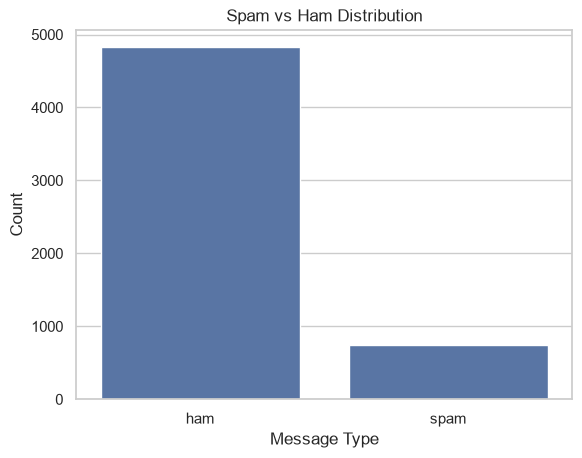

In [4]:
sns.countplot(data=df, x="label")
plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()


## 4. Text Preprocessing

Messages are converted to lowercase and punctuation/non-letter characters are removed. This creates a simpler text representation before TF-IDF feature extraction.


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)

df[["label", "message", "clean_message"]].head()


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## 5. TF-IDF Feature Extraction

**TF-IDF (Term Frequency–Inverse Document Frequency)** gives higher importance to words that are frequent in a particular message but less common across the entire collection of messages.


In [6]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_message"],
    df["label"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training matrix:", X_train.shape)
print("Testing matrix :", X_test.shape)


Training matrix: (4457, 5000)
Testing matrix : (1115, 5000)


## 6. Model Training

### 6.1 Multinomial Naive Bayes

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
pred_nb = nb_model.predict(X_test)


### 6.2 Logistic Regression

In [8]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)


### 6.3 Linear SVM

In [9]:
svm_model = LinearSVC(random_state=RANDOM_STATE)
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)


## 7. Model Evaluation

In [10]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="spam"),
        "Recall": recall_score(y_true, y_pred, pos_label="spam"),
        "F1 Score": f1_score(y_true, y_pred, pos_label="spam")
    }

results = pd.DataFrame([
    evaluate("Multinomial Naive Bayes", y_test, pred_nb),
    evaluate("Logistic Regression", y_test, pred_lr),
    evaluate("Linear SVM", y_test, pred_svm)
]).set_index("Model")

display(results.sort_values("F1 Score", ascending=False))


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Linear SVM,0.983857,0.985185,0.892617,0.936620
Logistic Regression,0.970404,0.991525,0.785235,0.876404
Multinomial Naive Bayes,0.969507,0.991453,0.778523,0.872180


### Why is recall important for spam detection?

Recall measures how many of the **actual spam messages** are correctly identified.

A low recall means many spam messages are incorrectly classified as legitimate messages. In a real spam-filtering system, this can allow unwanted or potentially harmful messages to reach the user's inbox.

However, precision is also important because incorrectly marking legitimate messages as spam can cause users to miss important communication.


## 8. Confusion Matrix — Best Model

Best Model: Linear SVM

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



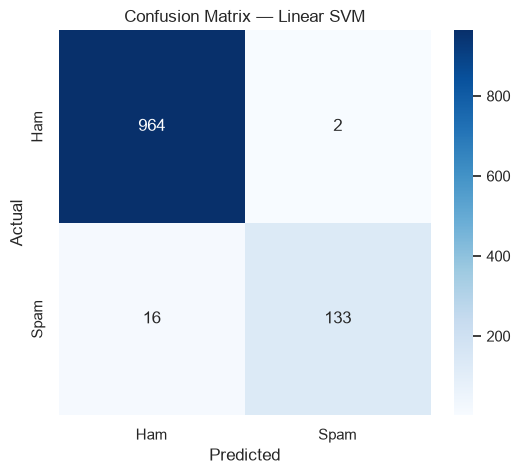

In [11]:
predictions = {
    "Multinomial Naive Bayes": pred_nb,
    "Logistic Regression": pred_lr,
    "Linear SVM": pred_svm
}

best_model_name = results["F1 Score"].idxmax()
best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=["ham", "spam"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


## 9. Final Prediction

In [12]:
new_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we still meeting for class today?"
]

new_clean = [clean_text(message) for message in new_messages]
new_features = vectorizer.transform(new_clean)

predictions_new = best_pred_model = {
    "Multinomial Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model
}[best_model_name].predict(new_features)

for message, prediction in zip(new_messages, predictions_new):
    print(f"Message: {message}")
    print(f"Prediction: {prediction}\n")


Message: Congratulations! You have won a free prize. Call now!
Prediction: spam

Message: Hey, are we still meeting for class today?
Prediction: ham



## 10. Conclusion

In [13]:
print("Best Model:", best_model_name)
print("Accuracy:", round(results.loc[best_model_name, "Accuracy"], 4))
print("Precision:", round(results.loc[best_model_name, "Precision"], 4))
print("Recall:", round(results.loc[best_model_name, "Recall"], 4))
print("F1 Score:", round(results.loc[best_model_name, "F1 Score"], 4))


Best Model: Linear SVM
Accuracy: 0.9839
Precision: 0.9852
Recall: 0.8926
F1 Score: 0.9366
